## A note book to create simulated-experimental image pairs using Cryosim
To use, simply replace the paths to the desired .cs and .mrc files that contain the particle CTFs and stack.

In [1]:
import sys

import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import torch
from tqdm import tqdm

sys.path.append("../src/")
from cryosparc_utils import extract_parameters_from_csfile
from filters import butter, normalize_particles
from imagegenerator import ImageGenerator
from pdb2mrc import PDB2MRC
from plotting_tools import plot3d

%load_ext autoreload
%autoreload 2

## Load raw images and .cs file

In [2]:
path = "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/J35_passthrough_particles.cs"  # all particles
(
    energy,
    orig_pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
) = extract_parameters_from_csfile(path, return_class="all")

rotations.shape, translations_A.shape, ctf_params.shape

(torch.Size([11108, 4]), torch.Size([11108, 2]), torch.Size([11108, 9]))

In [3]:
anisomag.shape

torch.Size([11108, 2, 2])

In [4]:
if anisomag is not None:
    # correct for anisotropic shift
    corrected_shifts = translations_A.unsqueeze(-1)  # Add a dimension to make it (B, 2, 1)
    
    # Perform batch matrix multiplication
    corrected_shifts = torch.bmm(anisomag, corrected_shifts)
    
    # Remove the last dimension to get (5, 2)
    corrected_shifts = corrected_shifts.squeeze(-1)
    translations_A = corrected_shifts

In [5]:
path = "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"  # cryosieve_iter10
with mrcfile.open(path) as mrc:
    raw_images = torch.tensor(mrc.data)
raw_images.shape

torch.Size([11108, 256, 256])

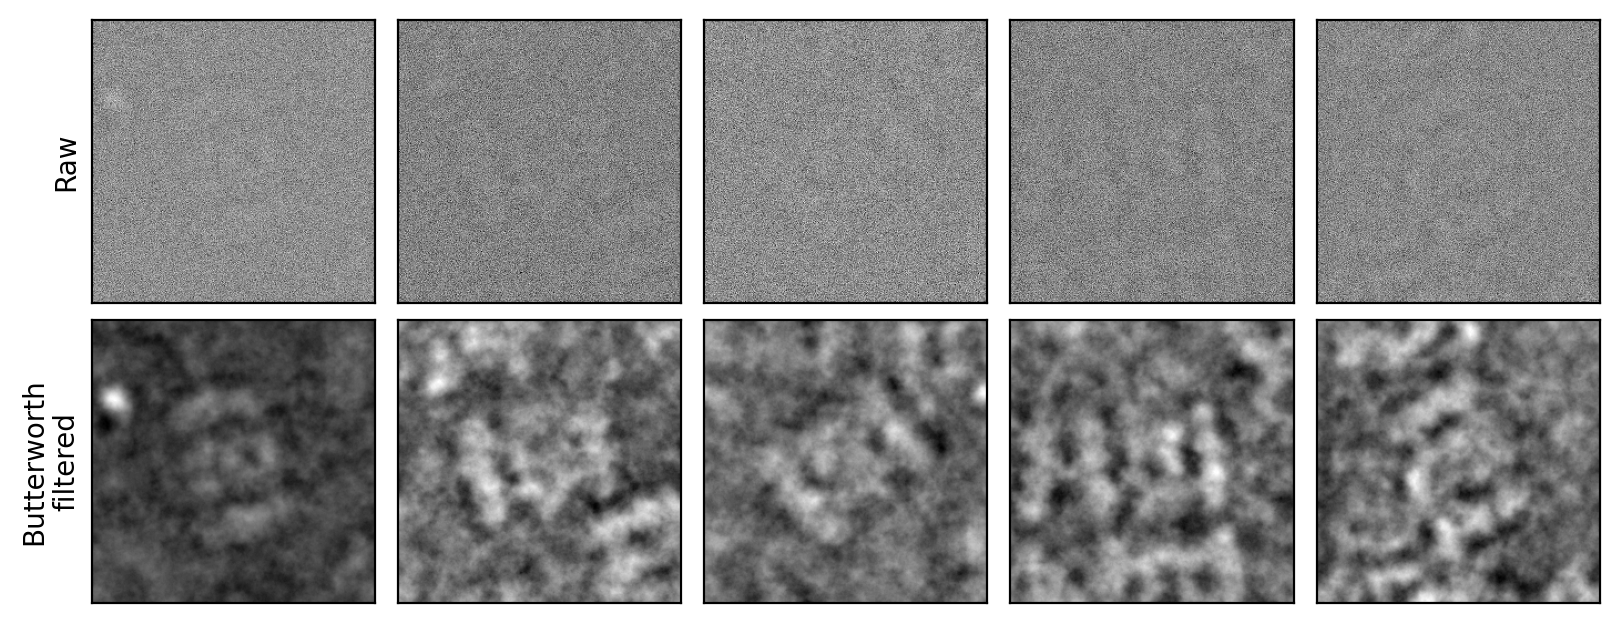

In [6]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(8, 3))
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(5):
    axes[0, i].imshow(raw_images[i], cmap="grey")
    axes[1, i].imshow(butter(raw_images[i]), cmap="grey")
axes[0, 0].set_ylabel("Raw")
axes[1, 0].set_ylabel("Butterworth\nfiltered")
plt.show()

## Generate 3D map

In [7]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "6BDF"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

../pdb-data/6BDF
PDB file saved to: ../pdb-data/6BDF.cif


/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 45654.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 45675.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 45706.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 45727.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain E is discontinuous at line 45758.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/c

In [8]:
# Samples 3D scattering potential onto specified grid
n = raw_images.shape[-1]  # number of pixels per axis
dx = orig_pixel_size  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

/mnt/cbis/home/e0788253/czii/cryosim/dev-notebooks/../src/potential.py:445: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  atom_size_px = int(torch.ceil(torch.tensor(3 / dx)) // 2 * 2 + 1)
100%|█████████████████████████████████████████████| 4/4 [00:03<00:00,  1.04it/s]


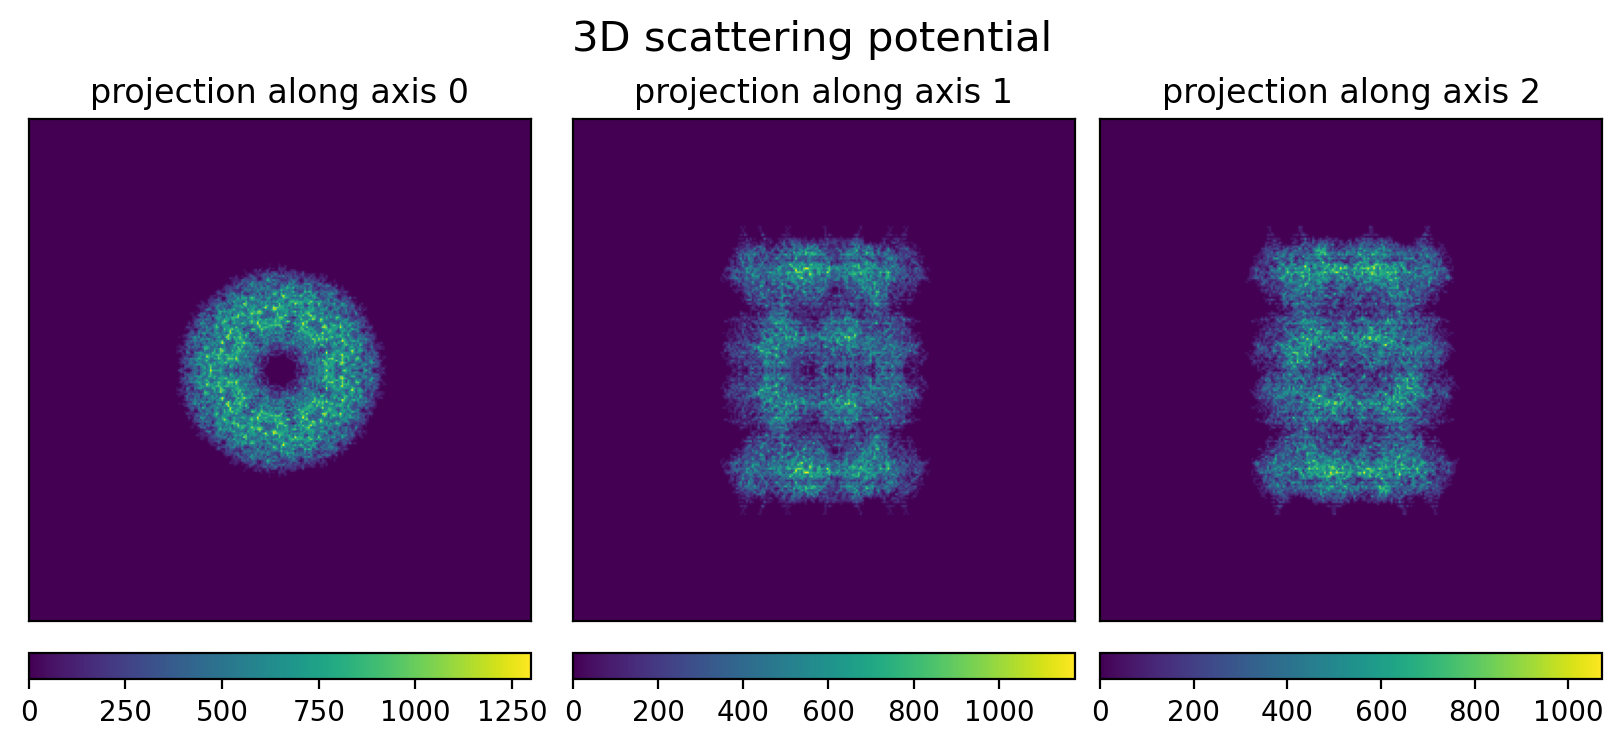

In [9]:
plot3d(V, title="3D scattering potential")

## Create simulated images
Note: we're using a trivial icing model here (randomly placed ice atoms) as our ice-making machine is still unoptimized.

In [10]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [11]:
## IMPORTANT ##
# We noticed that we have to artificially scale down
# our computed 3D scattering potentials to match
# the contrast seen in experimental images. This likely implies
# our physical model might still be missing something.
# this fudge scaling factor is a duct-tape solution for now.

fudge_scaling_factor = 0.2

In [12]:
num_particles = 10
dose_per_angstrom = 53

# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'
noise_model = "poisson"  # 'poisson' or None
ice_model = "randomchoice"  # 'randomchoice' or None
ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

noisy_model = ImageGenerator(
    V * fudge_scaling_factor,
    dx,
    rotations[:num_particles],
    translations_A[:num_particles],
    ctf_params[:num_particles],
    energy,
    dose_per_angstrom,
    anisomag=anisomag,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    flip_curvature=False, # relates to +ve or -ve Ewald sphere curvature
    alpha=alpha,
).to(device)

clean_model = ImageGenerator(
    V * fudge_scaling_factor,
    dx,
    rotations[:num_particles],
    translations_A[:num_particles],
    ctf_params[:num_particles],
    energy,
    dose_per_angstrom,
    anisomag=anisomag,
    ice_model=None,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=None,
    flip_curvature=False, # relates to +ve or -ve Ewald sphere curvature
    alpha=alpha,
).to(device)

Ice thickness is smaller than particle size. Reseting ice thickness to particle size.


In [13]:
idx = torch.arange(num_particles)
noisy_images = []
clean_images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in tqdm(range(0, num_particles, batchsize)):
        image = noisy_model(idx[i : i + batchsize])
        noisy_images.append(image.detach().cpu())
        
        image = clean_model(idx[i : i + batchsize])
        clean_images.append(image.detach().cpu())

clean_images = torch.concat(clean_images, dim=0)
noisy_images = torch.concat(noisy_images, dim=0)
clean_images.shape, noisy_images.shape

100%|█████████████████████████████████████████████| 2/2 [00:07<00:00,  3.52s/it]


(torch.Size([10, 256, 256]), torch.Size([10, 256, 256]))

In [14]:
# standard normalization procedure to match cryoSPARC
means, stds, normalized_particles = normalize_particles(noisy_images)
inverted_particles = -normalized_particles

clean_particles = -(clean_images - dose_per_angstrom) / np.sqrt(dose_per_angstrom)

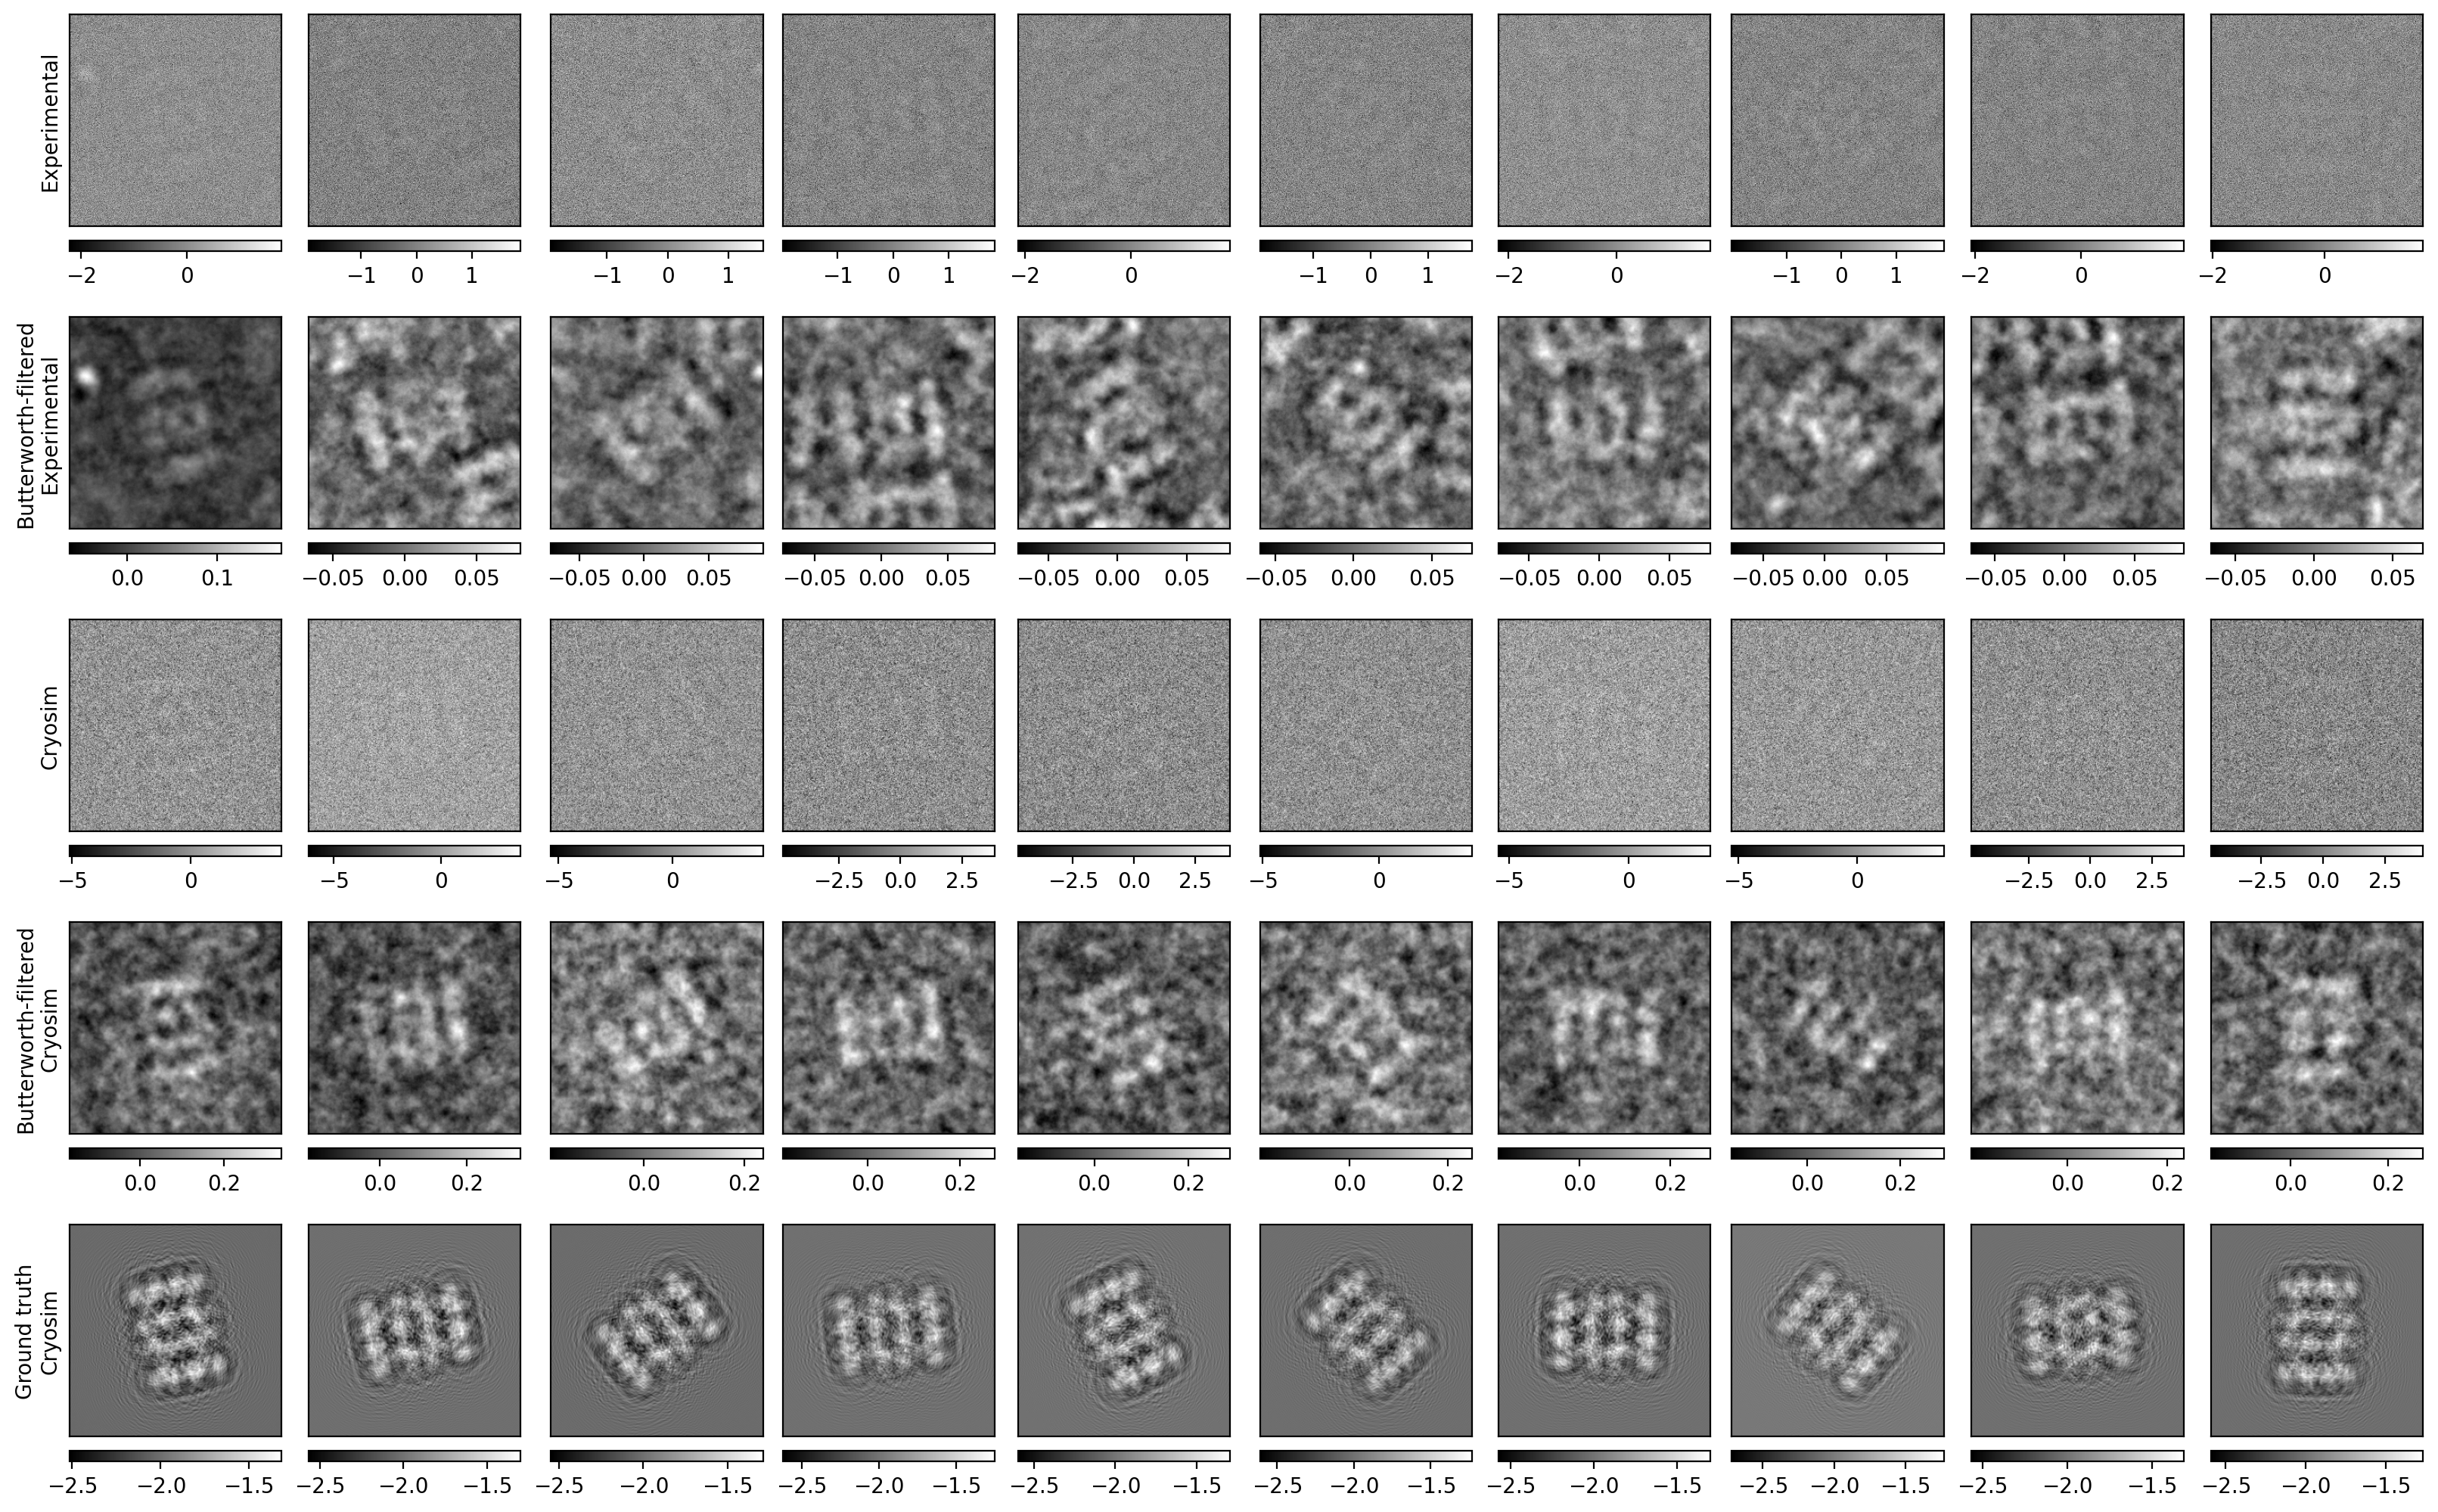

In [15]:
fig, axes = plt.subplots(5, 10, dpi=200, constrained_layout=True, figsize=(16, 10))
for i in range(10):
    im = axes[0, i].imshow(raw_images[i], cmap="grey")
    axes[0, i].set(xticks=[], yticks=[])
    fig.colorbar(im, ax=axes[0, i], location="bottom")

    im = axes[1, i].imshow(butter(raw_images[i]), cmap="grey")
    axes[1, i].set(xticks=[], yticks=[])
    fig.colorbar(im, ax=axes[1, i], location="bottom")
    
    im = axes[2, i].imshow(inverted_particles[i], cmap="grey")
    axes[2, i].set(xticks=[], yticks=[])
    fig.colorbar(im, ax=axes[2, i], location="bottom")
    
    im = axes[3, i].imshow(butter(inverted_particles[i]), cmap="grey")
    axes[3, i].set(xticks=[], yticks=[])
    fig.colorbar(im, ax=axes[3, i], location="bottom")
    
    im = axes[4, i].imshow(clean_particles[i], cmap="grey")
    axes[4, i].set(xticks=[], yticks=[])
    fig.colorbar(im, ax=axes[4, i], location="bottom")
axes[0,0].set_ylabel('Experimental')
axes[1,0].set_ylabel('Butterworth-filtered\nExperimental')
axes[2,0].set_ylabel('Cryosim')
axes[3,0].set_ylabel('Butterworth-filtered\nCryosim')
axes[4,0].set_ylabel('Ground truth\nCryosim')
plt.show()